In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt 
import pandas as pd 
from keras.datasets import mnist # credits to CX Team for introducing me to MNIST

I found Ma'am Jing's module hard to follow for this activity, and so I consulted other resources.
I used 3Blue1Brown's series on Neural Network as an introduction, and then consulted the book he
suggested "Neural Networks and Deep Learning" by Nielsen M. found in this link: http://neuralnetworksanddeeplearning.com/index.html

I use the MNIST database to train the neural network, I now understand why sir Chester emphasized its 
importance in one of our parallel meetings!

In [2]:
'''
train_X: uint8 NumPy array of grayscale image data with shapes (60000, 28, 28), containing the training data. Pixel values range from 0 to 255.

train_y: uint8 NumPy array of digit labels (integers in range 0-9) with shape (60000,) for the training data.

test_X: uint8 NumPy array of grayscale image data with shapes (10000, 28, 28), containing the test data. Pixel values range from 0 to 255.

test_y: uint8 NumPy array of digit labels (integers in range 0-9) with shape (10000,) for the test data.
'''

(train_X, train_y), (test_X, test_y) = mnist.load_data()

Text(0.5, 1.0, 'First MNIST Training Data - Class: 5')

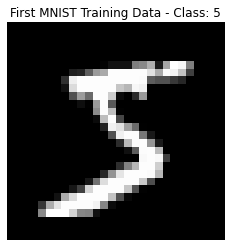

In [3]:
plt.imshow(train_X[0], cmap='gray')
plt.axis('off')
plt.title('First MNIST Training Data - Class: '+str(train_y[0]))

Text(0.5, 1.0, 'First MNIST Testing Data - Class: 7')

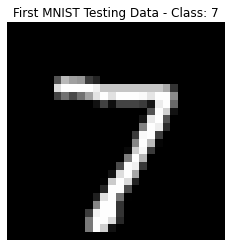

In [4]:
plt.imshow(test_X[0], cmap='gray')
plt.axis('off')
plt.title('First MNIST Testing Data - Class: '+str(test_y[0]))

In [5]:
'''
This block creates train_Y and test_Y, which are 2D arrays with 10 rows corresponding to each digit in MNIST
and number of columns corresponding to the number of training and test data respectively. They are basically
class labels in binary form as to avoid errors in computation later on. 

So basically;
train_y = an integer 0-9
train_Y = one-hot encoded, for one image if the classification is 4 it outputs [0,0,0,0,1,0,0,0,0,0]
          as a col vector, we then stack all the resulting unit column vectors to a 2D array. 

Why do this? The neural network implementation below requires the training data classifications to be
one-hot encoded. 
'''

# One-hot encoding
train_Y = np.zeros((train_y.max()+1, train_y.shape[0])) 
train_Y[train_y, np.arange(train_y.shape[0])] = 1
test_Y = np.zeros((test_y.max()+1, len(test_y)))
test_Y[test_y, np.arange(len(test_y))]=1 
# print(train_Y)


In [6]:
'''
Now we zip the training data.
First element is a 784 len array, each element corresponding to a pixel value which we normalize
Second element is a 10 len array, one-hot encoded, but just the corresponding column vector

NOTE: 
 - .T is the transpose, a built-in numpy function I just learned to use instead of np.transpose() lul
 - for test_data we used test_y (not capital so not one-hot encoded) since we only require the digit itself
'''

training_data =  [((np.array(image).flatten()/255).reshape(-1,1), unit_vector.reshape(-1,1)) for image, unit_vector in zip(train_X, train_Y.T)]
test_data = [((np.array(image).flatten()/255).reshape(-1,1), digit.reshape(-1,1)) for image, digit in zip(test_X, test_y)]
# print(len(training_data[0][0]), len(training_data[0][1]))
# print(max(training_data[0][0]), min(training_data[0][0]))


In [7]:
'''
Args:
sizes - list, contains the number of neurons per layer. The first layer is the input layer while the 
        last is automatically the output layer. In our case, a list [60, 10, 2, 9] means there are 60
        inputs, 10 and 2 hidden neurons, then 9 outputs.
        
Out:
a neural network that can be trained with SGD (stochastic gradient descent), watch 3b1b video series 
on neural networks istg pls it's so intuitive...

NOTE:
You can only use overfit_test() after using SGD() because the former uses self.scores...
'''


class Network(object):

    def __init__(self, sizes):
        ''' The biases and weights for the network are initialized randomly, using a Gaussian
        distribution with mean 0, and variance 1.  Note that the first layer is assumed to be
        an input layer, and by convention we won't set any biases for those neurons (hence the [1:]),
        since biases are only ever used in computing the outputs from later layers.'''
        self.num_layers = len(sizes)
        self.sizes = sizes
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]]
        self.weights = [np.random.randn(y, x)
                        for x, y in zip(sizes[:-1], sizes[1:])]
        self.scores = []  # this is used in the SGD method, and is used to store accuracies for each
                          # epoch for later plotting

    def feedforward(self, a):
        '''Return the output of the network if "a" is input.'''
        for b, w in zip(self.biases, self.weights):
            a = sigmoid(np.dot(w, a)+b)
        return a

    def SGD(self, training_data, epochs, mini_batch_size, eta,
            test_data=None):
        
        ''' Train the neural network using mini-batch stochastic gradient descent in order to
        shorten computation times. The gist is you shuffle the training data randomly then
        divide them by batches, training your network for each batch. 
        
        Args:
        training_data - list of tuples (x,y); x is the image itself, flattened into a column vector
        and normalized to values 0-1. On the other hand, y is a one-hot encoded classification for 
        each x. If x is an image of the digit '5', y should be a col vector [0,0,0,0,0,1,0,0,0,0]. 
        
        epochs - number of iterations for training
        mini_batch_size - number of images for each batch; the lower it is the noisier the training
        "signal" will be, the higher it is the longer the computation for gradients in each step will be
        
        NOTE: If "test_data" is provided, the network will be tested for each epoch with respect to it.
        This lets you keep track of any overshooting, but makes computation time a lot bigger. 
        If you just want to evaluate the final neural network, just use the evaluate method defined...
        I defined a list "scores" to store the results for each epoch...
        '''
        if test_data: n_test = len(test_data)
        n = len(training_data)
        scores = []
        for j in range(epochs):
            random.shuffle(training_data)
            mini_batches = [
                training_data[k:k+mini_batch_size]
                for k in range(0, n, mini_batch_size)]
            for mini_batch in mini_batches:
                self.update_mini_batch(mini_batch, eta)
            if test_data:
                self.scores.append(self.evaluate(test_data)/n_test)
                print("Epoch {0}: {1} / {2}".format(j, self.evaluate(test_data), n_test))
            else:
                print ("Epoch {0} complete".format(j))

    def update_mini_batch(self, mini_batch, eta):
        '''Update the network's weights and biases by applying
        gradient descent using backpropagation to a single mini batch.
        The ``mini_batch`` is a list of tuples ``(x, y)``, and ``eta``
        is the learning rate.'''
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x, y)
            nabla_b = [nb+dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
            nabla_w = [nw+dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]
        self.weights = [w-(eta/len(mini_batch))*nw
                        for w, nw in zip(self.weights, nabla_w)]
        self.biases = [b-(eta/len(mini_batch))*nb
                       for b, nb in zip(self.biases, nabla_b)]

    def backprop(self, x, y):
        """Return a tuple ``(nabla_b, nabla_w)`` representing the
        gradient for the cost function C_x.  ``nabla_b`` and
        ``nabla_w`` are layer-by-layer lists of numpy arrays, similar
        to ``self.biases`` and ``self.weights``."""
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        # feedforward
        activation = x
        activations = [x] # list to store all the activations, layer by layer
        zs = [] # list to store all the z vectors, layer by layer
        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, activation)+b
            zs.append(z)
            activation = sigmoid(z)
            activations.append(activation)
        # backward pass
        delta = self.cost_derivative(activations[-1], y) * \
            sigmoid_prime(zs[-1])
        nabla_b[-1] = delta
        nabla_w[-1] = np.dot(delta, activations[-2].transpose())
        # Note that the variable l in the loop below is used a little
        # differently to the notation in Chapter 2 of the book.  Here,
        # l = 1 means the last layer of neurons, l = 2 is the
        # second-last layer, and so on.  It's a renumbering of the
        # scheme in the book, used here to take advantage of the fact
        # that Python can use negative indices in lists.
        for l in range(2, self.num_layers):
            z = zs[-l]
            sp = sigmoid_prime(z)
            delta = np.dot(self.weights[-l+1].transpose(), delta) * sp
            nabla_b[-l] = delta
            nabla_w[-l] = np.dot(delta, activations[-l-1].transpose())
        return (nabla_b, nabla_w)

    def evaluate(self, test_data):
        """Return the number of test inputs for which the neural
        network outputs the correct result. Note that the neural
        network's output is assumed to be the index of whichever
        neuron in the final layer has the highest activation."""
        test_results = [(np.argmax(self.feedforward(x)), y)
                        for (x, y) in test_data]
        return sum(int(x == y) for (x, y) in test_results)   # num of correct answers by network
    
    def overfit_test(self):
        '''
        This method graphs the accuracies obtained when you supply a test_data argument in SGD()
        '''
        epoch_count = list(range(len(self.scores)))   # indices for plotting [0, 1, 2, ...]
        max_accuracy = max(self.scores)
        max_epoch = self.scores.index(max(self.scores))
        
        plt.bar(epoch_count, self.scores)
        text = f'Highest Accuracy: {max_accuracy}\nEpoch: {max_epoch}'
        plt.text(0.60, 0.1, text, transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round'))
        plt.xlabel('Epoch')
        plt.ylabel('Accuracies (0-1)')
        plt.title('Neural Network Accuracy over Epochs')
    
    def cost_derivative(self, output_activations, y):
        """Return the vector of partial derivatives \partial C_x /
        \partial a for the output activations."""
        return (output_activations-y)

# Activation function stuff
def sigmoid(z):
    """The sigmoid function."""
    return 1.0/(1.0+np.exp(-z))

def sigmoid_prime(z):
    """Derivative of the sigmoid function."""
    return sigmoid(z)*(1-sigmoid(z))

In [8]:
neural_net = Network([784, 16, 16, 10])   # 784 for MNIST grid, 30 in hidden layer, then 10 digits for output
neural_net.SGD(training_data = training_data, epochs = 30, mini_batch_size = 10, eta = 6.0, test_data = test_data )

Epoch 0: 8964 / 10000
Epoch 1: 9169 / 10000
Epoch 2: 9120 / 10000
Epoch 3: 9244 / 10000
Epoch 4: 9144 / 10000
Epoch 5: 9265 / 10000
Epoch 6: 9259 / 10000
Epoch 7: 9290 / 10000
Epoch 8: 9248 / 10000
Epoch 9: 9255 / 10000
Epoch 10: 9198 / 10000
Epoch 11: 9270 / 10000
Epoch 12: 9285 / 10000
Epoch 13: 9212 / 10000
Epoch 14: 9321 / 10000
Epoch 15: 9287 / 10000
Epoch 16: 9318 / 10000
Epoch 17: 9334 / 10000
Epoch 18: 9388 / 10000
Epoch 19: 9212 / 10000
Epoch 20: 9209 / 10000
Epoch 21: 9345 / 10000
Epoch 22: 9372 / 10000
Epoch 23: 9326 / 10000
Epoch 24: 9360 / 10000
Epoch 25: 9380 / 10000
Epoch 26: 9378 / 10000
Epoch 27: 9359 / 10000
Epoch 28: 9370 / 10000
Epoch 29: 9359 / 10000


In [9]:
neural_net.evaluate(test_data = test_data)

9359

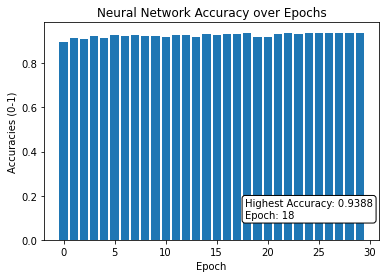

In [10]:
neural_net.overfit_test()